# GSE44076: Check the Paired Tumor-Normal Design

This notebook checks whether tumor and paired normal mucosa samples can be matched reliably from the GEO metadata. A paired probe-level comparison is run only after confirming one tumor and one paired-normal sample per individual identifier.

The analysis remains exploratory. Adjusted p-values and probe rankings are not biological claims, biomarkers, or evidence of clinical relevance.

## Setup

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.analysis import (  # noqa: E402
    build_paired_sample_table,
    derive_pair_ids,
    paired_ttest_by_probe,
)
from src.geo_loader import (  # noqa: E402
    align_expression_with_metadata,
    build_sample_metadata_table,
    convert_expression_to_numeric,
    load_geo_expression_table,
    read_geo_series_lines,
)

RAW_PATH = PROJECT_ROOT / "data" / "raw" / "GSE44076_series_matrix.txt.gz"
METADATA_PATH = PROJECT_ROOT / "data" / "processed" / "sample_metadata.csv"
OUTPUT_PATH = PROJECT_ROOT / "data" / "processed" / "tumor_vs_paired_normal_paired_probe_ranking.csv"
FIGURE_DIR = PROJECT_ROOT / "reports" / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

GROUP_MAP = {
    "Healthy colon mucosa cells": "healthy_mucosa",
    "Normal distant colon mucosa cells": "paired_normal_mucosa",
    "Primary colon adenocarcinoma cells": "tumor",
}

plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})

## Load and Align Data

In [2]:
if not RAW_PATH.is_file():
    raise FileNotFoundError(
        "GSE44076 series matrix not found. Place the downloaded file at "
        f"{RAW_PATH}"
    )

expression = load_geo_expression_table(RAW_PATH)
if METADATA_PATH.is_file():
    sample_metadata = pd.read_csv(METADATA_PATH)
else:
    sample_metadata = build_sample_metadata_table(read_geo_series_lines(RAW_PATH))

if "group" not in sample_metadata:
    sample_metadata["group"] = sample_metadata["source_name"].map(GROUP_MAP)
if sample_metadata["group"].isna().any():
    raise ValueError("Some sample source names do not have a documented group label.")

expression, sample_metadata = align_expression_with_metadata(expression, sample_metadata)
expression = convert_expression_to_numeric(expression)

print(f"Aligned expression table: {expression.shape}")
print(f"Metadata table: {sample_metadata.shape}")
print(f"Missing numeric values: {int(expression.drop(columns='ID_REF').isna().sum().sum()):,}")

Aligned expression table: (49386, 247)
Metadata table: (246, 10)
Missing numeric values: 0


## Inspect Pairing Metadata

The series matrix includes an `individual_id` characteristic. Titles also contain the same identifiers in forms such as `Normal paired sample from A2004 patient` and `Tumor sample from A2004 patient`. Because the identifier is explicit and consistent across both groups, it is used as the pair ID; no identifier is inferred from expression values.

In [3]:
comparison_metadata = sample_metadata[
    sample_metadata["group"].isin(["tumor", "paired_normal_mucosa"])
].copy()
comparison_metadata = derive_pair_ids(comparison_metadata)

display(
    comparison_metadata[
        ["sample_accession", "title", "source_name", "individual_id", "pair_id", "group"]
    ].head(10)
)
print(f"Tumor samples: {(comparison_metadata['group'] == 'tumor').sum()}")
print(f"Paired-normal samples: {(comparison_metadata['group'] == 'paired_normal_mucosa').sum()}")
print(f"Missing pair IDs: {comparison_metadata['pair_id'].isna().sum()}")
print(
    "Duplicate pair/group records: "
    f"{comparison_metadata.duplicated(['pair_id', 'group'], keep=False).sum()}"
)

,sample_accession,title,source_name,individual_id,pair_id,group
50,GSM1077648,Normal paired sample from A2004 patient,Normal distant colon mucosa cells,A2004,A2004,paired_normal_mucosa
51,GSM1077649,Normal paired sample from A2027 patient,Normal distant colon mucosa cells,A2027,A2027,paired_normal_mucosa
52,GSM1077650,Normal paired sample from A2050 patient,Normal distant colon mucosa cells,A2050,A2050,paired_normal_mucosa
53,GSM1077651,Normal paired sample from A2096 patient,Normal distant colon mucosa cells,A2096,A2096,paired_normal_mucosa
54,GSM1077652,Normal paired sample from B2012 patient,Normal distant colon mucosa cells,B2012,B2012,paired_normal_mucosa
55,GSM1077653,Normal paired sample from B2035 patient,Normal distant colon mucosa cells,B2035,B2035,paired_normal_mucosa
56,GSM1077654,Normal paired sample from B2058 patient,Normal distant colon mucosa cells,B2058,B2058,paired_normal_mucosa
57,GSM1077655,Normal paired sample from B2081 patient,Normal distant colon mucosa cells,B2081,B2081,paired_normal_mucosa
58,GSM1077656,Normal paired sample from C2021 patient,Normal distant colon mucosa cells,C2021,C2021,paired_normal_mucosa
59,GSM1077657,Normal paired sample from C2044 patient,Normal distant colon mucosa cells,C2044,C2044,paired_normal_mucosa


Tumor samples: 98
Paired-normal samples: 98
Missing pair IDs: 0
Duplicate pair/group records: 0


## Build and Validate the Pair Table

A reliable pair requires exactly one tumor and one paired-normal accession for the same `pair_id`. Incomplete or duplicated records would be reported before testing.

In [4]:
pair_counts = comparison_metadata.groupby(["pair_id", "group"]).size().unstack(fill_value=0)
complete_mask = (
    (pair_counts.get("tumor", 0) == 1)
    & (pair_counts.get("paired_normal_mucosa", 0) == 1)
)
unmatched_pairs = pair_counts.loc[~complete_mask]
pair_table = build_paired_sample_table(comparison_metadata, "group", "pair_id")

print(f"Distinct candidate pair IDs: {len(pair_counts)}")
print(f"Complete matched pairs: {len(pair_table)}")
print(f"Unmatched or incomplete pair IDs: {len(unmatched_pairs)}")
display(unmatched_pairs)
display(pair_table.head())

reliable_pairing = (
    len(pair_table) > 0
    and len(unmatched_pairs) == 0
    and not comparison_metadata["pair_id"].isna().any()
)
print(f"Pairing criteria satisfied: {reliable_pairing}")

Distinct candidate pair IDs: 98
Complete matched pairs: 98
Unmatched or incomplete pair IDs: 0


group,paired_normal_mucosa,tumor
pair_id,,


,pair_id,paired_normal_mucosa,tumor
0,A2004,GSM1077648,GSM1077746
1,A2027,GSM1077649,GSM1077747
2,A2050,GSM1077650,GSM1077748
3,A2096,GSM1077651,GSM1077749
4,B2012,GSM1077652,GSM1077750


Pairing criteria satisfied: True


## Paired Probe-Level Comparison

Because all pairing checks pass, tumor-minus-normal differences are computed within each of the 98 individuals. A paired t-test is then applied per probe, followed by Benjamini-Hochberg adjustment.

In [5]:
if not reliable_pairing:
    raise RuntimeError(
        "Reliable pairs could not be recovered; paired statistical testing was not performed."
    )

paired_ranking = paired_ttest_by_probe(
    expression,
    pair_table,
    tumor_column="tumor",
    normal_column="paired_normal_mucosa",
)
OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)
paired_ranking.to_csv(OUTPUT_PATH, index=False)

print(f"Probes compared: {len(paired_ranking):,}")
print(f"Pairs used per probe: {len(pair_table)}")
print(f"Saved local ranking: {OUTPUT_PATH.relative_to(PROJECT_ROOT)}")
display(paired_ranking.head(10))

Probes compared: 49,386
Pairs used per probe: 98
Saved local ranking: data\processed\tumor_vs_paired_normal_paired_probe_ranking.csv


,probe_id,mean_tumor,mean_paired_normal,mean_paired_difference,p_value,adjusted_p_value
0,11728232_a_at,8.911113,3.990905,4.920208,1.041866e-63,5.145358e-59
1,11735833_a_at,8.206537,3.507156,4.699381,1.015939e-62,2.508659e-58
2,11719434_a_at,7.215302,3.918255,3.297047,5.088328e-60,8.376406e-56
3,11728234_a_at,7.406224,3.181895,4.224330,7.084812e-60,8.495091e-56
4,11721993_at,8.194611,4.890877,3.303735,8.600708e-60,8.495091e-56
5,11733581_a_at,2.814294,7.465294,-4.651000,6.784517e-59,5.584336e-55
6,11739128_a_at,7.707634,4.115249,3.592385,9.857737e-59,6.954774e-55
7,11759464_at,2.747332,7.904841,-5.157509,8.186109e-58,5.053490e-54
8,11732838_at,3.747131,10.294447,-6.547316,4.616173e-57,2.533048e-53
9,11721557_a_at,3.780091,8.060342,-4.280251,6.511778e-56,2.923551e-52


## Paired Ranking Summary

Adjusted p-value counts describe this dataset under the paired t-test assumptions. They do not establish biological importance, reproducibility, or clinical meaning.

In [6]:
fdr_counts = pd.Series(
    {
        "adjusted_p_value < 0.05": int((paired_ranking["adjusted_p_value"] < 0.05).sum()),
        "adjusted_p_value < 0.01": int((paired_ranking["adjusted_p_value"] < 0.01).sum()),
        "adjusted_p_value < 0.001": int((paired_ranking["adjusted_p_value"] < 0.001).sum()),
    },
    name="probe_count",
)
display(fdr_counts.to_frame())

top_absolute_difference = (
    paired_ranking.assign(
        absolute_paired_difference=paired_ranking["mean_paired_difference"].abs()
    )
    .sort_values(["absolute_paired_difference", "adjusted_p_value"], ascending=[False, True])
    .head(10)
)
display(top_absolute_difference)

,probe_count
adjusted_p_value < 0.05,33414
adjusted_p_value < 0.01,29578
adjusted_p_value < 0.001,25728


,probe_id,mean_tumor,mean_paired_normal,mean_paired_difference,p_value,adjusted_p_value,absolute_paired_difference
89,11729583_x_at,4.582909,12.300246,-7.717337,1.334416e-47,7.322387e-45,7.717337
392,11728771_a_at,4.890284,12.159907,-7.269623,8.154854e-41,1.024773e-38,7.269623
96,11729582_s_at,3.803621,10.780727,-6.977105,2.266106e-47,1.153751e-44,6.977105
20,11737294_a_at,3.137554,10.066269,-6.928715,4.584550e-53,1.078155e-49,6.928715
13,11726764_at,3.807132,10.423790,-6.616658,6.808791e-55,2.401850e-51,6.616658
285,11733744_at,5.079228,11.686735,-6.607507,2.446454e-42,4.222565e-40,6.607507
8,11732838_at,3.747131,10.294447,-6.547316,4.616173e-57,2.533048e-53,6.547316
1058,11722059_at,6.235244,12.613878,-6.378634,2.008591e-35,9.366977e-34,6.378634
274,11730973_a_at,4.607981,10.819588,-6.211607,1.719373e-42,3.076556e-40,6.211607
120,11731957_at,6.299352,12.347068,-6.047716,2.454228e-46,1.001690e-43,6.047716


## Paired Exploratory Volcano Plot

The x-axis is the mean within-pair tumor-minus-normal difference. Highlighting uses adjusted p-value below 0.05 and absolute mean paired difference of at least 1 only to organize the visualization.

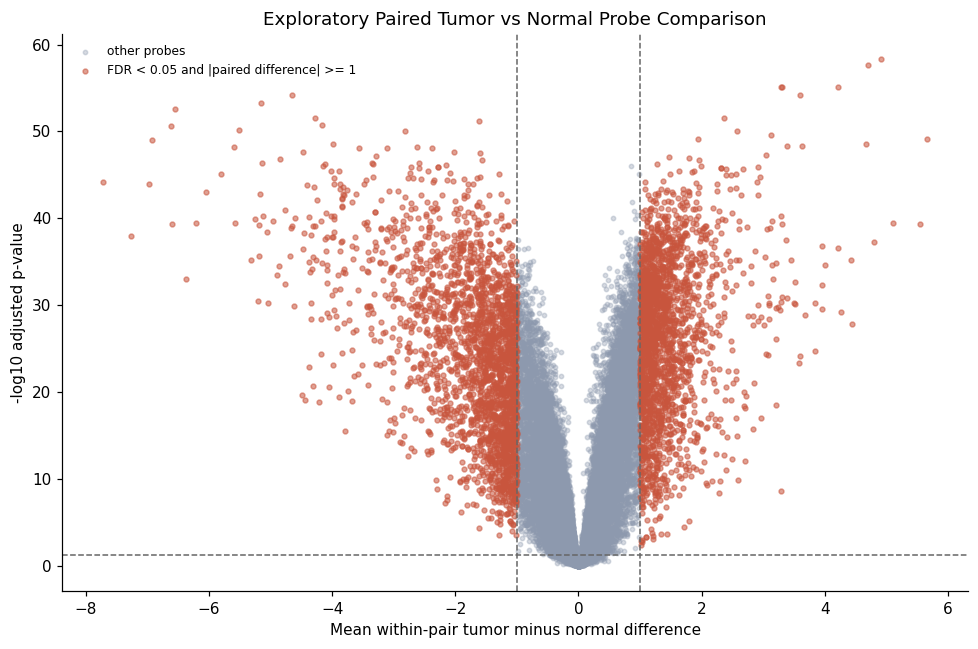

In [7]:
plot_table = paired_ranking.copy()
plot_table["minus_log10_adjusted_p"] = -np.log10(
    plot_table["adjusted_p_value"].clip(lower=np.finfo(float).tiny)
)
plot_table["highlight"] = (
    (plot_table["adjusted_p_value"] < 0.05)
    & (plot_table["mean_paired_difference"].abs() >= 1)
)

fig, ax = plt.subplots(figsize=(9, 6))
background = plot_table[~plot_table["highlight"]]
highlighted = plot_table[plot_table["highlight"]]
ax.scatter(
    background["mean_paired_difference"],
    background["minus_log10_adjusted_p"],
    s=8,
    alpha=0.35,
    color="#8D99AE",
    label="other probes",
)
ax.scatter(
    highlighted["mean_paired_difference"],
    highlighted["minus_log10_adjusted_p"],
    s=10,
    alpha=0.55,
    color="#C8553D",
    label="FDR < 0.05 and |paired difference| >= 1",
)
ax.axvline(-1, color="#666666", linestyle="--", linewidth=1)
ax.axvline(1, color="#666666", linestyle="--", linewidth=1)
ax.axhline(-np.log10(0.05), color="#666666", linestyle="--", linewidth=1)
ax.set_title("Exploratory Paired Tumor vs Normal Probe Comparison")
ax.set_xlabel("Mean within-pair tumor minus normal difference")
ax.set_ylabel("-log10 adjusted p-value")
ax.legend(frameon=False, fontsize=8)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "paired_tumor_vs_normal_volcano.png", dpi=180, bbox_inches="tight")
plt.show()

## Top-Ranked Within-Pair Differences

The heatmap displays tumor-minus-normal differences for 20 top-ranked probes across 98 individuals. It is a probe-level methodological view, not a biomarker heatmap.

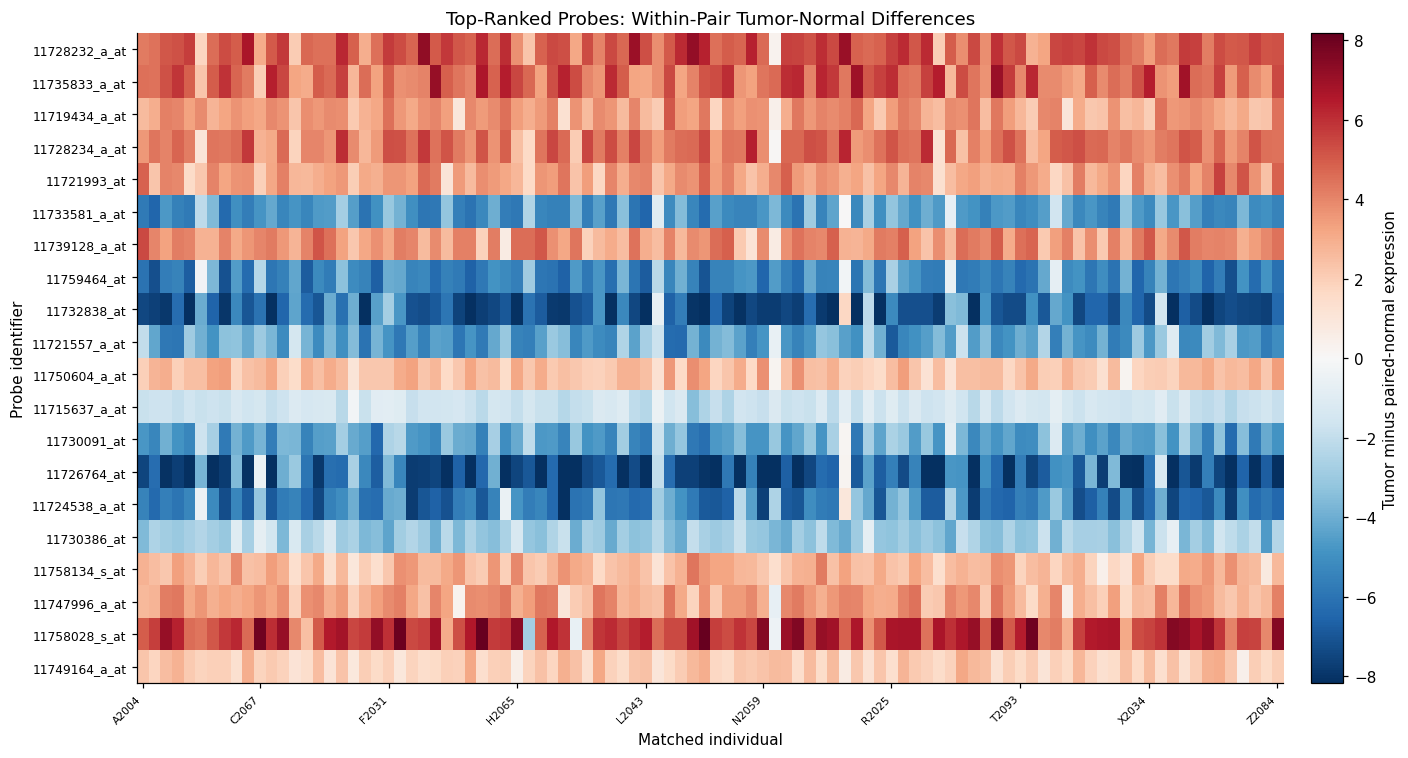

In [8]:
top_probe_ids = paired_ranking.head(20)["probe_id"].tolist()
indexed_expression = expression.set_index("ID_REF")
tumor_values = indexed_expression.loc[top_probe_ids, pair_table["tumor"]].to_numpy()
normal_values = indexed_expression.loc[
    top_probe_ids,
    pair_table["paired_normal_mucosa"],
].to_numpy()
paired_differences = pd.DataFrame(
    tumor_values - normal_values,
    index=top_probe_ids,
    columns=pair_table["pair_id"],
)
color_limit = float(np.nanquantile(np.abs(paired_differences.to_numpy()), 0.98))

fig, ax = plt.subplots(figsize=(14, 7))
image = ax.imshow(
    paired_differences,
    aspect="auto",
    cmap="RdBu_r",
    vmin=-color_limit,
    vmax=color_limit,
)
ax.set_title("Top-Ranked Probes: Within-Pair Tumor-Normal Differences")
ax.set_xlabel("Matched individual")
ax.set_ylabel("Probe identifier")
ax.set_yticks(range(len(top_probe_ids)), labels=top_probe_ids, fontsize=8)
tick_positions = np.linspace(0, len(pair_table) - 1, 10, dtype=int)
ax.set_xticks(tick_positions, labels=pair_table.iloc[tick_positions]["pair_id"], rotation=45, ha="right", fontsize=7)
colorbar = fig.colorbar(image, ax=ax, pad=0.02)
colorbar.set_label("Tumor minus paired-normal expression")
fig.tight_layout()
fig.savefig(
    FIGURE_DIR / "paired_top_probe_difference_heatmap.png",
    dpi=180,
    bbox_inches="tight",
)
plt.show()

## Comparison with the Unpaired First Pass

The paired and unpaired analyses produce broadly related but non-identical rankings. The paired test uses the recoverable within-individual structure and is therefore the more appropriate simple comparison for these 98 matched pairs. Similarity between rankings does not validate individual probes, while differences illustrate why study design must be represented explicitly.

Further work should confirm platform annotation and preprocessing, inspect paired-difference assumptions, consider robust or model-based alternatives, and avoid gene-level interpretation until probe annotation is established.